Untitled1.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1Acj8GudBObKgEP8dsznOO52B5TRL2lQM

In [14]:
# -*- coding: utf-8 -*-

# =========================
# PHASE 1 — TITANIC CLASSIFICATION
# =========================


import pandas as pd  # استيراد مكتبة pandas للتعامل مع البيانات
import numpy as np   # استيراد مكتبة numpy للعمليات الرياضية

# sklearn imports
from sklearn.model_selection import train_test_split  # لتقسيم البيانات تدريب/اختبار
from sklearn.preprocessing import StandardScaler       # scallingلتوحيد القياسات للميزات العددية
from sklearn.linear_model import LogisticRegression    # Logistic Regression model
from sklearn.ensemble import RandomForestClassifier    # Random Forest model
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)             # Evaluation metrics
import matplotlib.pyplot as plt  # للرسومات
import seaborn as sns            # للرسومات

In [15]:
# 1) Load data
url = "titanic.csv.csv"  # رابط داتا Titanic
df = pd.read_csv(url)  # تحميل الداتا إلى DataFrame
#عشان يعرف يقراها

In [16]:
print(df.columns)
# sibsp الاخوه
# parch children
# fare price for ticket
# embarked from where came

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [17]:
# 3) Handle missing values
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])  # تعويض القيم المفقودة لأكثر شيوعًا
#عمود Embarked يمثل ميناء صعود الشخص على السفينة#

# Age -> median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fare -> median
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

# Drop Cabin (many missing) + Name + Ticket
df = df.drop(columns=["Cabin", "Name", "Ticket"], errors="ignore")

In [18]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='object')


In [19]:
# 4) Encode categorical features
# Sex (male/female) + Embarked + Pclass as categorical
df["Pclass"] = df["Pclass"].astype(str)

df_encoded = pd.get_dummies(df, columns=["Sex", "Embarked", "Pclass"], drop_first=True)

In [20]:
# 5) Split data
X = df_encoded.drop("Survived", axis=1)
y = df_encoded["Survived"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (623, 10) Val: (134, 10) Test: (134, 10)


In [21]:
# 6) Scale numeric features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

Logistic Regression Results:
Accuracy: 0.746268656716418
Precision: 0.673469387755102
Recall: 0.6470588235294118
F1: 0.66
ROC-AUC: 0.8029766123316796

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80        83
           1       0.67      0.65      0.66        51

    accuracy                           0.75       134
   macro avg       0.73      0.73      0.73       134
weighted avg       0.74      0.75      0.75       134



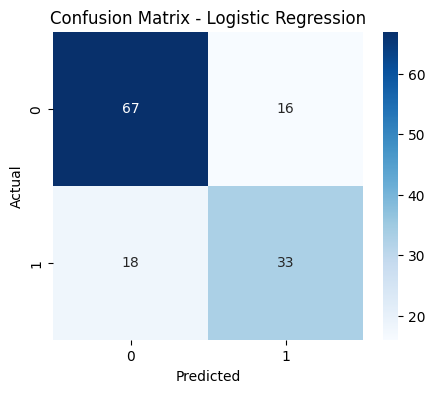

In [22]:
# 7) Model 1: Logistic Regression (Baseline)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# رسم مصفوفة الارتباك فقط
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Results:
Accuracy: 0.7910447761194029
Precision: 0.7674418604651163
Recall: 0.6470588235294118
F1: 0.7021276595744681
ROC-AUC: 0.8262461611150484

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84        83
           1       0.77      0.65      0.70        51

    accuracy                           0.79       134
   macro avg       0.78      0.76      0.77       134
weighted avg       0.79      0.79      0.79       134



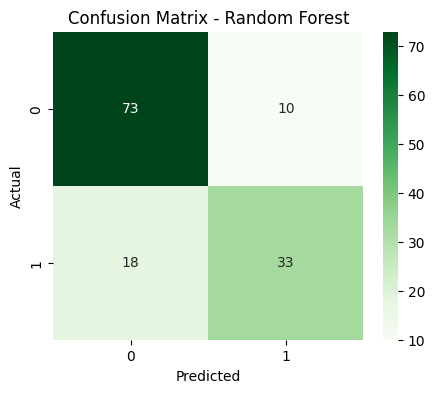

In [23]:
# 8) Model 2: Random Forest (Advanced)
rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# رسم مصفوفة الارتباك فقط
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()